# Editing analysis



In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import scipy.stats
import os
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects
import warnings
warnings.filterwarnings('ignore')
plt.rc('font', family='Helvetica')

# SAV analysis

In [121]:
library = pd.read_csv('../../source_data/02_library/CDK_library_final.csv')


#-----load single amino-acid variants (SAVs) breakdown for each subpool------
SAV_ABE1 = pd.read_csv('../../screening_data/04_editing/SAVs/ABE_subpool1.zip')
SAV_ABE1 = pd.merge(SAV_ABE1, library[['gRNA_id', 'Gene']], on='gRNA_id')

SAV_CBE1 = pd.read_csv('../../screening_data/04_editing/SAVs/CBE_subpool1.zip')
SAV_CBE1 = pd.merge(SAV_CBE1, library[['gRNA_id', 'Gene']], on='gRNA_id')


SAV_ABE2 = pd.read_csv('../../screening_data/04_editing/SAVs/ABE_subpool2.zip')
SAV_ABE2 = pd.merge(SAV_ABE2, library[['gRNA_id', 'Gene']], on='gRNA_id')

SAV_CBE2 = pd.read_csv('../../screening_data/04_editing/SAVs/CBE_subpool2.zip')
SAV_CBE2 = pd.merge(SAV_CBE2, library[['gRNA_id', 'Gene']], on='gRNA_id')


SAV_ABE3 = pd.read_csv('../../screening_data/04_editing/SAVs/ABE_subpool3.zip')
SAV_ABE3 = pd.merge(SAV_ABE3, library[['gRNA_id', 'Gene']], on='gRNA_id')

SAV_CBE3 = pd.read_csv('../../screening_data/04_editing/SAVs/CBE_subpool3.zip')
SAV_CBE3 =  pd.merge(SAV_CBE3, library[['gRNA_id', 'Gene']], on='gRNA_id')

#------also load the raw editing for each (i.e. with compound mutations) -------

ABE1 = pd.read_csv('../../screening_data/04_editing/ABE_subpool1_HGVSp.zip')
CBE1 = pd.read_csv('../../screening_data/04_editing/CBE_subpool1_HGVSp.zip')
ABE2 = pd.read_csv('../../screening_data/04_editing/ABE_CDK12_13_HGVSp.zip')
CBE2 = pd.read_csv('../../screening_data/04_editing/CBE_CDK12_13_HGVSp.zip')
ABE3 = pd.read_csv('../../screening_data/04_editing/ABE_CDK2_4_6_HGVSp.zip')
CBE3 = pd.read_csv('../../screening_data/04_editing/CBE_CDK2_4_6_HGVSp.zip')

In [129]:
#define the possible codon and SAV substitutions
CDK_info = pd.read_csv('../../source_data/01_library_generation_files/cdks_info_updated.csv')

genes = ['CDK7', 'CDK8', 'CDK19', 'CDK9', 'CDK12', 'CDK13', 'CDK2', 'CDK4', 'CDK6']

CDK_info = CDK_info[CDK_info['Gene'].isin(genes)].reset_index(drop=True)

aas = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y', '*']


var_holder_possible = []
cod_holder_possible = []

for gene in genes:
    pp = CDK_info.loc[CDK_info['Gene']==gene, 'Protein'].values[0]
    var_possible = []
    cod_possible = []

    for kk, val in enumerate(pp):
        orig_aa = val
        codon_loc = int(kk+1) #account for off-by-one indexing
        cod_possible.append(codon_loc)

        for aa in aas:
            if aa!=orig_aa:
                var_possible.append(f'{orig_aa}{codon_loc}{aa}')

    var_holder_possible.append(var_possible)
    cod_holder_possible.append(cod_possible)


variants_dict_possible = dict(zip(genes, var_holder_possible))
cod_dict_possible = dict(zip(genes, cod_holder_possible))

In [130]:
def subset_calc_var(gene1, ABE, CBE, variants_dict_possible, edit_cutoff):

    list1 = CBE[CBE['Gene']==gene1]
    list2 = ABE[ABE['Gene']==gene1]
    list3 = variants_dict_possible[gene1]

    list1 = list1[list1['%Reads']>=edit_cutoff]['HGVSp']
    list2 = list2[list2['%Reads']>=edit_cutoff]['HGVSp']

    set1 = set(list1)
    set2 = set(list2)
    set3 = set(list3)

    subset1 = len(set1 - set2 - set3)  # Only in set1
    subset2 = len(set2 - set1 - set3)  # Only in set2
    subset3 = len(set3 - set1 - set2)  # Only in set3
    subset12 = len(set1.intersection(set2) - set3)  # In set1 and set2, but not set3
    subset13 = len(set1.intersection(set3) - set2)  # In set1 and set3, but not set2
    subset23 = len(set2.intersection(set3) - set1)  # In set2 and set3, but not set1
    subset123 = len(set1.intersection(set2).intersection(set3))  # In all three sets

    subsets = (subset1, subset2, subset12, subset3, subset13, subset23, subset123)

    return subsets

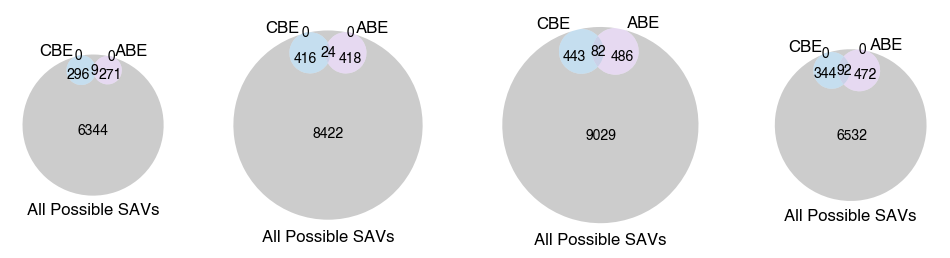

In [124]:

from matplotlib_venn import venn3


edit_cutoff = 10
subset_CDK7 = subset_calc_var('CDK7', SAV_ABE1, SAV_CBE1, variants_dict_possible, edit_cutoff)
subset_CDK8 = subset_calc_var('CDK8', SAV_ABE1, SAV_CBE1, variants_dict_possible, edit_cutoff)
subset_CDK19 = subset_calc_var('CDK19', SAV_ABE1, SAV_CBE1, variants_dict_possible, edit_cutoff)
subset_CDK9 = subset_calc_var('CDK9', SAV_ABE1, SAV_CBE1, variants_dict_possible, edit_cutoff)


ratios = [sum(v) for v in [subset_CDK7, subset_CDK8, subset_CDK19, subset_CDK9]]
norm = [n / sum(ratios) for n in ratios]

fig, ax = plt.subplots(1,4,figsize=(12,3), width_ratios=norm)


c = venn3(subsets=subset_CDK7, ax=ax[0], set_labels=('CBE', 'ABE', 'All Possible SAVs'), set_colors = ('tab:blue', 'tab:purple', 'grey'))
c2 = venn3(subsets=subset_CDK8, ax=ax[1], set_labels=('CBE', 'ABE', 'All Possible SAVs'), set_colors = ('tab:blue', 'tab:purple', 'grey'))
c3 = venn3(subsets=subset_CDK19, ax=ax[2], set_labels=('CBE', 'ABE', 'All Possible SAVs'), set_colors = ('tab:blue', 'tab:purple', 'grey'))
c4 = venn3(subsets=subset_CDK9, ax=ax[3], set_labels=('CBE', 'ABE', 'All Possible SAVs'), set_colors = ('tab:blue', 'tab:purple', 'grey'))

#fig.savefig(f'../../figures/venn_vars_subpool1_{edit_cutoff}.pdf', transparent=True)

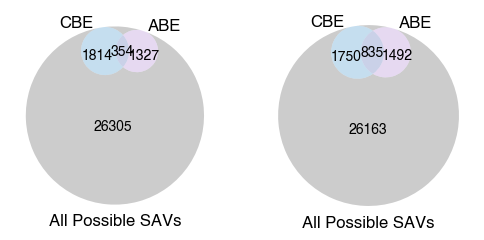

In [125]:
from matplotlib_venn import venn3


edit_cutoff = 10
subset_CDK12 = subset_calc_var('CDK12', SAV_ABE2, SAV_CBE2, variants_dict_possible, edit_cutoff)
subset_CDK13 = subset_calc_var('CDK13', SAV_ABE2, SAV_CBE2, variants_dict_possible, edit_cutoff)


ratios = [sum(v) for v in [subset_CDK12, subset_CDK13]]
norm = [n / sum(ratios) for n in ratios]

fig, ax = plt.subplots(1,2,figsize=(6,3), width_ratios=norm)

c = venn3(subsets=subset_CDK12, ax=ax[0], set_labels=('CBE', 'ABE', 'All Possible SAVs'), set_colors = ('tab:blue', 'tab:purple', 'grey'))
c2 = venn3(subsets=subset_CDK13, ax=ax[1], set_labels=('CBE', 'ABE', 'All Possible SAVs'), set_colors = ('tab:blue', 'tab:purple', 'grey'))

#fig.savefig(f'../../figures/venn_vars_subpool2_{edit_cutoff}.pdf', transparent=True)

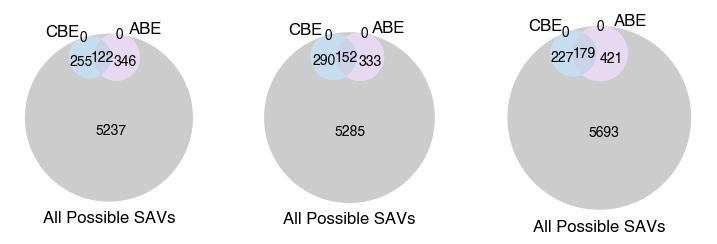

In [132]:
from matplotlib_venn import venn3


edit_cutoff = 10
subset_CDK2 = subset_calc_var('CDK2', SAV_ABE3, SAV_CBE3, variants_dict_possible, edit_cutoff)
subset_CDK4 = subset_calc_var('CDK4', SAV_ABE3, SAV_CBE3, variants_dict_possible, edit_cutoff)
subset_CDK6 = subset_calc_var('CDK6', SAV_ABE3, SAV_CBE3, variants_dict_possible, edit_cutoff)

ratios = [sum(v) for v in [subset_CDK2, subset_CDK4, subset_CDK6]]
norm = [n / sum(ratios) for n in ratios]

fig, ax = plt.subplots(1,3,figsize=(9,3), width_ratios=norm)

c = venn3(subsets=subset_CDK2, ax=ax[0], set_labels=('CBE', 'ABE', 'All Possible SAVs'), set_colors = ('tab:blue', 'tab:purple', 'grey'))
c2 = venn3(subsets=subset_CDK4, ax=ax[1], set_labels=('CBE', 'ABE', 'All Possible SAVs'), set_colors = ('tab:blue', 'tab:purple', 'grey'))
c3 = venn3(subsets=subset_CDK6, ax=ax[2], set_labels=('CBE', 'ABE', 'All Possible SAVs'), set_colors = ('tab:blue', 'tab:purple', 'grey'))

#fig.savefig(f'../../figures/venn_vars_subpool2_{edit_cutoff}.pdf', transparent=True)

In [134]:

def codon_calc(df):
    """ 
    Function for converting SAV df to sorting mutation rate by Codon for each gRNA
    i.e. sum %Reads by Codon for a given gRNA
    output excludes WT (but % remain accurate)
    """
    
    new = []
    for i in np.unique(df['gRNA_id']):
        sub = df[df['gRNA_id']==i][['Codon', '%Reads']].groupby('Codon').sum().reset_index()
        sub['gRNA_id'] = i
        new.append(sub)

    n_cod = pd.concat(new)
    n_cod = pd.merge(n_cod, library[['gRNA_id', 'Gene']], on='gRNA_id')

    n_cod = n_cod[n_cod['Codon']!='WT']
    n_cod['Codon'] = [int(i) for i in n_cod['Codon']]

    return n_cod

cod_ABE1 = codon_calc(SAV_ABE1)
cod_ABE2 = codon_calc(SAV_ABE2)
cod_ABE3 = codon_calc(SAV_ABE3)

cod_CBE1 = codon_calc(SAV_CBE1)
cod_CBE2 = codon_calc(SAV_CBE2)
cod_CBE3 = codon_calc(SAV_CBE3)

In [135]:

def subset_calc_cod(gene1, ABE, CBE, cod_dict_possible, edit_cutoff):
    list1 = CBE[CBE['Gene']==gene1]
    list2 = ABE[ABE['Gene']==gene1]

    list1 = list1[list1['%Reads']>=edit_cutoff]['Codon']
    list2 = list2[list2['%Reads']>=edit_cutoff]['Codon']

    list3 = cod_dict_possible[gene1]

    set1 = set(list1)
    set2 = set(list2)
    set3 = set(list3)

    subset1 = len(set1 - set2 - set3)  # Only in set1
    subset2 = len(set2 - set1 - set3)  # Only in set2
    subset3 = len(set3 - set1 - set2)  # Only in set3
    subset12 = len(set1.intersection(set2) - set3)  # In set1 and set2, but not set3
    subset13 = len(set1.intersection(set3) - set2)  # In set1 and set3, but not set2
    subset23 = len(set2.intersection(set3) - set1)  # In set2 and set3, but not set1
    subset123 = len(set1.intersection(set2).intersection(set3))  # In all three sets

    subsets = (subset1, subset2, subset12, subset3, subset13, subset23, subset123)

    return subsets

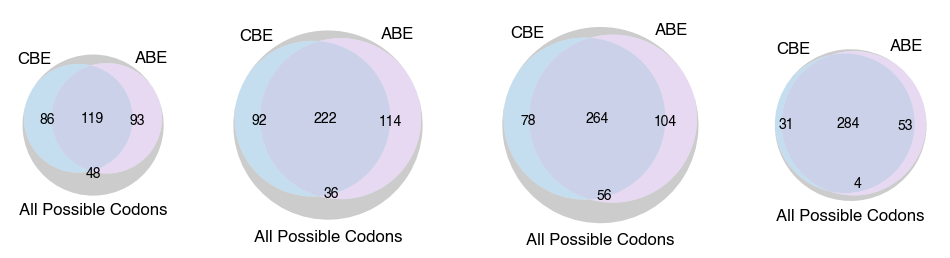

In [ ]:
edit_cutoff = 10

subset_CDK7 = subset_calc_cod('CDK7', cod_ABE1, cod_CBE1, cod_dict_possible, edit_cutoff)
subset_CDK8 = subset_calc_cod('CDK8', cod_ABE1, cod_CBE1, cod_dict_possible, edit_cutoff)
subset_CDK19 = subset_calc_cod('CDK19', cod_ABE1, cod_CBE1, cod_dict_possible, edit_cutoff)
subset_CDK9 = subset_calc_cod('CDK9', cod_ABE1, cod_CBE1, cod_dict_possible, edit_cutoff)


from matplotlib_venn import venn3

ratios = [sum(v) for v in [subset_CDK7, subset_CDK8, subset_CDK19, subset_CDK9]]
norm = [n / sum(ratios) for n in ratios]

fig, ax = plt.subplots(1,4,figsize=(12,3), width_ratios=norm)


c = venn3(subsets=subset_CDK7, ax=ax[0], set_labels=('CBE', 'ABE', 'All Possible Codons'), set_colors = ('tab:blue', 'tab:purple', 'grey'))
c2 = venn3(subsets=subset_CDK8, ax=ax[1], set_labels=('CBE', 'ABE', 'All Possible Codons'), set_colors = ('tab:blue', 'tab:purple', 'grey'))
c3 = venn3(subsets=subset_CDK19, ax=ax[2], set_labels=('CBE', 'ABE', 'All Possible Codons'), set_colors = ('tab:blue', 'tab:purple', 'grey'))
c4 = venn3(subsets=subset_CDK9, ax=ax[3], set_labels=('CBE', 'ABE', 'All Possible Codons'), set_colors = ('tab:blue', 'tab:purple', 'grey'))

#fig.savefig(f'../../figures/venn_codon_subpool1_{edit_cutoff}.pdf', transparent=True)

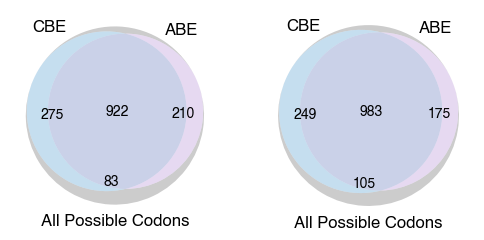

In [69]:
edit_cutoff = 10

subset_CDK12 = subset_calc_cod('CDK12', cod_ABE2, cod_CBE2, cod_dict_possible, edit_cutoff)
subset_CDK13 = subset_calc_cod('CDK13', cod_ABE2, cod_CBE2, cod_dict_possible, edit_cutoff)


from matplotlib_venn import venn3

ratios = [sum(v) for v in [subset_CDK12, subset_CDK13]]
norm = [n / sum(ratios) for n in ratios]

fig, ax = plt.subplots(1,2,figsize=(6,3), width_ratios=norm)

c = venn3(subsets=subset_CDK12, ax=ax[0], set_labels=('CBE', 'ABE', 'All Possible Codons'), set_colors = ('tab:blue', 'tab:purple', 'grey'))
c2 = venn3(subsets=subset_CDK13, ax=ax[1], set_labels=('CBE', 'ABE', 'All Possible Codons'), set_colors = ('tab:blue', 'tab:purple', 'grey'))


#fig.savefig(f'../../figures/venn_codon_cdk12_13_{edit_cutoff}.pdf', transparent=True)

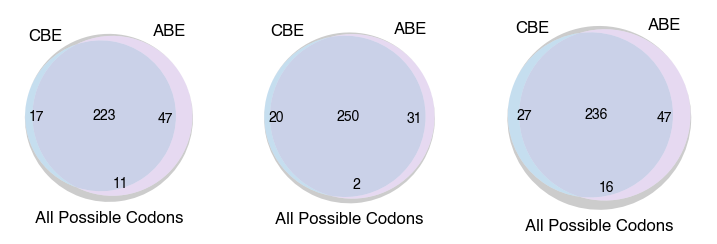

In [136]:
from matplotlib_venn import venn3


edit_cutoff = 10
subset_CDK2 = subset_calc_cod('CDK2', cod_ABE3, cod_CBE3, cod_dict_possible, edit_cutoff)
subset_CDK4 = subset_calc_cod('CDK4', cod_ABE3, cod_CBE3, cod_dict_possible, edit_cutoff)
subset_CDK6 = subset_calc_cod('CDK6', cod_ABE3, cod_CBE3, cod_dict_possible, edit_cutoff)

ratios = [sum(v) for v in [subset_CDK2, subset_CDK4, subset_CDK6]]
norm = [n / sum(ratios) for n in ratios]

fig, ax = plt.subplots(1,3,figsize=(9,3), width_ratios=norm)

c = venn3(subsets=subset_CDK2, ax=ax[0], set_labels=('CBE', 'ABE', 'All Possible Codons'), set_colors = ('tab:blue', 'tab:purple', 'grey'))
c2 = venn3(subsets=subset_CDK4, ax=ax[1], set_labels=('CBE', 'ABE', 'All Possible Codons'), set_colors = ('tab:blue', 'tab:purple', 'grey'))
c3 = venn3(subsets=subset_CDK6, ax=ax[2], set_labels=('CBE', 'ABE', 'All Possible Codons'), set_colors = ('tab:blue', 'tab:purple', 'grey'))

In [137]:
genes = ['CDK7', 'CDK8', 'CDK19', 'CDK9', 'CDK12', 'CDK13', 'CDK2', 'CDK4', 'CDK6']


var_cols = [f'{gene}_total_vars' for gene in genes]
var_cols_CBE = [f'{gene}_CBE_vars' for gene in genes]
var_cols_ABE = [f'{gene}_ABE_vars' for gene in genes]

cod_cols = [f'{gene}_total_codons' for gene in genes]
cod_cols_CBE = [f'{gene}_CBE_codons' for gene in genes]
cod_cols_ABE = [f'{gene}_ABE_codons' for gene in genes]

cols = ['editing_cutoff'] + var_cols + var_cols_CBE + var_cols_ABE + cod_cols + cod_cols_ABE + cod_cols_CBE

plotting_df = pd.DataFrame(dict(zip(cols, [list(range(0,101))] + [np.zeros(101) for i in range(6*3*2)])))
plotting_df

,editing_cutoff,CDK7_total_vars,CDK8_total_vars,CDK19_total_vars,CDK9_total_vars,CDK12_total_vars,CDK13_total_vars,CDK2_total_vars,CDK4_total_vars,CDK6_total_vars,...,CDK6_ABE_vars,CDK7_total_codons,CDK8_total_codons,CDK19_total_codons,CDK9_total_codons,CDK12_total_codons,CDK13_total_codons,CDK2_total_codons,CDK4_total_codons,CDK6_total_codons
0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,96,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
97,97,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
98,98,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
99,99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# And then plot as a function of editing cutoff

In [138]:
genes = ['CDK7', 'CDK8', 'CDK19', 'CDK9', 'CDK12', 'CDK13', 'CDK2', 'CDK4', 'CDK6']


var_cols = [f'{gene}_total_vars' for gene in genes]
var_cols_CBE = [f'{gene}_CBE_vars' for gene in genes]
var_cols_ABE = [f'{gene}_ABE_vars' for gene in genes]

cod_cols = [f'{gene}_total_codons' for gene in genes]
cod_cols_CBE = [f'{gene}_CBE_codons' for gene in genes]
cod_cols_ABE = [f'{gene}_ABE_codons' for gene in genes]

cols = ['editing_cutoff'] + var_cols + var_cols_CBE + var_cols_ABE + cod_cols + cod_cols_ABE + cod_cols_CBE

plotting_df = pd.DataFrame(dict(zip(cols, [list(range(0,101))] + [np.zeros(101) for i in range(9*3*2)])))

for edit_cutoff in range(0,101):

    for gene in genes:

        if gene in ['CDK7', 'CDK8', 'CDK9', 'CDK19']:
            codons = subset_calc_cod(gene, cod_ABE1, cod_CBE1, cod_dict_possible, edit_cutoff)
            vars = subset_calc_var(gene, SAV_ABE1, SAV_CBE1, variants_dict_possible, edit_cutoff)

        elif gene in ['CDK12', 'CDK13']:
            codons = subset_calc_cod(gene, cod_ABE2, cod_CBE2, cod_dict_possible, edit_cutoff)
            vars = subset_calc_var(gene, SAV_ABE2, SAV_CBE2, variants_dict_possible, edit_cutoff)

        elif gene in ['CDK2', 'CDK4', 'CDK6']:
            codons = subset_calc_cod(gene, cod_ABE3, cod_CBE3, cod_dict_possible, edit_cutoff)
            vars = subset_calc_var(gene, SAV_ABE3, SAV_CBE3, variants_dict_possible, edit_cutoff)



        #add var info
        ABE_subset = vars[5]
        CBE_subset = vars[4]
        shared = vars[6]
        missing = vars[3]

        total_inc = ABE_subset + CBE_subset + shared
        total = ABE_subset+ CBE_subset + shared + missing
        frac = 100*(total_inc/total)

        plotting_df.loc[plotting_df['editing_cutoff']==edit_cutoff, f'{gene}_total_vars'] = frac
        plotting_df.loc[plotting_df['editing_cutoff']==edit_cutoff, f'{gene}_ABE_vars'] = 100*((ABE_subset+shared)/total)
        plotting_df.loc[plotting_df['editing_cutoff']==edit_cutoff, f'{gene}_CBE_vars'] = 100*((CBE_subset+shared)/total)

        #and add cod info
        ABE_subset = codons[5]
        CBE_subset = codons[4]
        shared = codons[6]
        missing = codons[3]

        total_inc = ABE_subset + CBE_subset + shared
        total = ABE_subset+ CBE_subset + shared + missing
        frac = 100*(total_inc/total)

        plotting_df.loc[plotting_df['editing_cutoff']==edit_cutoff, f'{gene}_total_codons'] = frac
        plotting_df.loc[plotting_df['editing_cutoff']==edit_cutoff, f'{gene}_ABE_codons'] = 100*((ABE_subset+shared)/total)
        plotting_df.loc[plotting_df['editing_cutoff']==edit_cutoff, f'{gene}_CBE_codons'] = 100*((CBE_subset+shared)/total)




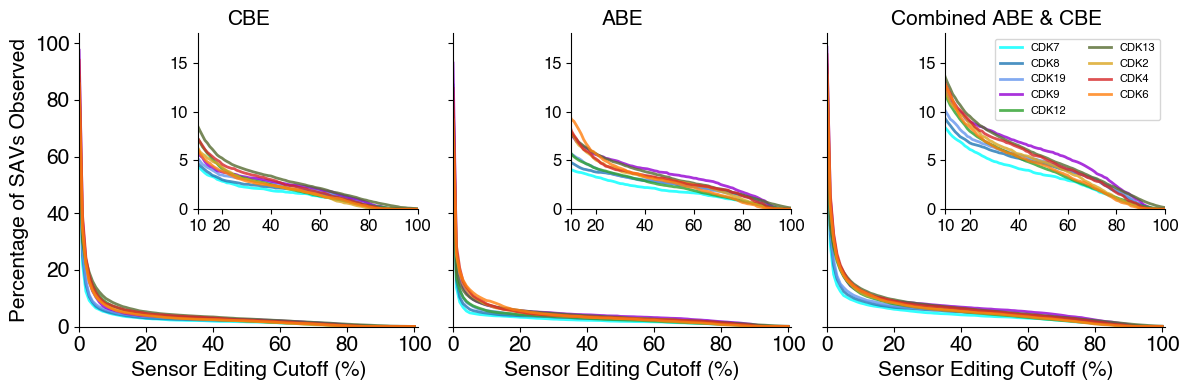

In [139]:


fig, ax = plt.subplots(1,3, figsize=(12,4), sharey=True, sharex=True)
ins1 = ax[0].inset_axes([0.35,.4,0.65,0.6])
ins2 = ax[1].inset_axes([0.35,.4,0.65,0.6])
ins3 = ax[2].inset_axes([0.35,.4,0.65,0.6])

color_dict = {'CDK7':'cyan', 
              'CDK8':'tab:blue', 
              'CDK19':'cornflowerblue', 
              'CDK9':'darkviolet', 
              'CDK12':'tab:green', 
              'CDK13':'darkolivegreen',
              'CDK2':'goldenrod',
              'CDK4':'tab:red', 
              'CDK6':'tab:orange',}

for gene in genes:

    ax[0].plot(plotting_df['editing_cutoff'], plotting_df[f'{gene}_CBE_vars'], label=f'{gene} CBE', linewidth=2, alpha=.8, c=color_dict[gene])
    ins1.plot(plotting_df['editing_cutoff'], plotting_df[f'{gene}_CBE_vars'], label=f'{gene} CBE', linewidth=2, alpha=.8, c=color_dict[gene])


for gene in genes:

    ax[1].plot(plotting_df['editing_cutoff'], plotting_df[f'{gene}_ABE_vars'], label=f'{gene} ABE', linewidth=2, alpha=.8, c=color_dict[gene])
    ins2.plot(plotting_df['editing_cutoff'], plotting_df[f'{gene}_ABE_vars'], label=f'{gene} ABE', linewidth=2, alpha=.8, c=color_dict[gene])


for gene in genes:
    ax[2].plot(plotting_df['editing_cutoff'], plotting_df[f'{gene}_total_vars'], label=f'{gene}', linewidth=2, alpha=.8, c=color_dict[gene])
    ins3.plot(plotting_df['editing_cutoff'], plotting_df[f'{gene}_total_vars'], label=f'{gene}', linewidth=2, alpha=.8, c=color_dict[gene])

#inset parameters
ins1.spines[['right', 'top']].set_visible(False)
ins1.tick_params(axis='both', which='major', labelsize=12)
ins1.set_xlim(10,100)
ins1.set_ylim(0,18)
ins2.spines[['right', 'top']].set_visible(False)
ins2.tick_params(axis='both', which='major', labelsize=12)
ins2.set_xlim(10,100)
ins2.set_ylim(0,18)
ins3.spines[['right', 'top']].set_visible(False)
ins3.tick_params(axis='both', which='major', labelsize=12)
ins3.set_xlim(10,100)
ins3.set_ylim(0,18)


ins1.set_xticks([10,20,40,60,80,100])
ins2.set_xticks([10,20,40,60,80,100])
ins3.set_xticks([10,20,40,60,80,100])


#other params
ax[0].set_ylabel('Percentage of SAVs Observed', fontsize=15)
ax[0].set_xlabel('Sensor Editing Cutoff (%)', fontsize=15)
ax[1].set_xlabel('Sensor Editing Cutoff (%)', fontsize=15)
ax[2].set_xlabel('Sensor Editing Cutoff (%)', fontsize=15)

ax[0].set_xlim(0,101)
ax[0].set_ylim(0,)

ax[0].set_xticks([0,20,40,60,80,100])
ax[0].spines[['right', 'top']].set_visible(False)
ax[0].tick_params(axis='both', which='major', labelsize=15)
ax[1].spines[['right', 'top']].set_visible(False)
ax[1].tick_params(axis='both', which='major', labelsize=15)
ax[2].spines[['right', 'top']].set_visible(False)
ax[2].tick_params(axis='both', which='major', labelsize=15)

ax[2].legend(fontsize=8, ncol=2)
ax[0].set_title('CBE', fontsize=15)
ax[1].set_title('ABE', fontsize=15)
ax[2].set_title('Combined ABE & CBE', fontsize=15)

fig.tight_layout()
#fig.savefig(f'../../figures/vars_by_edit_cutoff.pdf', transparent=True)

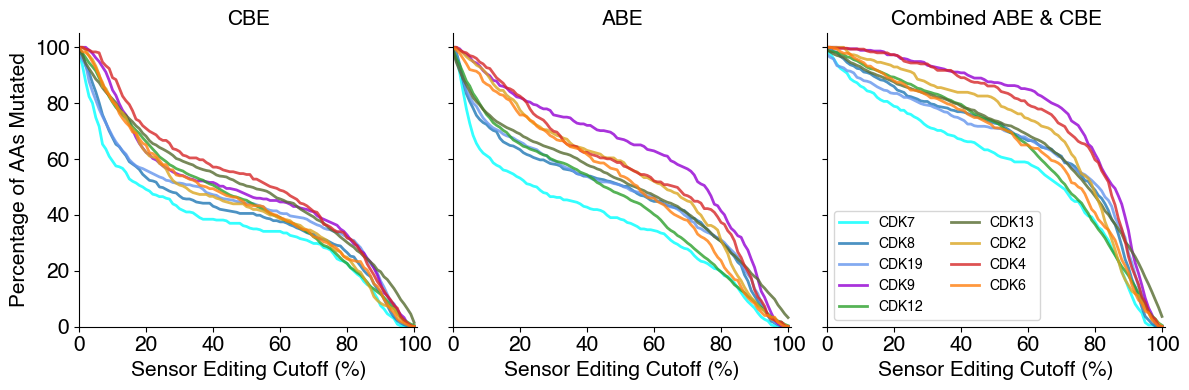

In [141]:


fig, ax = plt.subplots(1,3, figsize=(12,4), sharey=True, sharex=True)


color_dict = {'CDK7':'cyan', 
              'CDK8':'tab:blue', 
              'CDK19':'cornflowerblue', 
              'CDK9':'darkviolet', 
              'CDK12':'tab:green', 
              'CDK13':'darkolivegreen',
              'CDK2':'goldenrod',
              'CDK4':'tab:red', 
              'CDK6':'tab:orange',}

for gene in genes:

    ax[0].plot(plotting_df['editing_cutoff'], plotting_df[f'{gene}_CBE_codons'], label=f'{gene} CBE', linewidth=2, alpha=.8, c=color_dict[gene])
    #ins1.plot(plotting_df['editing_cutoff'], plotting_df[f'{gene}_CBE_vars'], label=f'{gene} CBE', linewidth=2, alpha=.8, c=color_dict[gene])


for gene in genes:

    ax[1].plot(plotting_df['editing_cutoff'], plotting_df[f'{gene}_ABE_codons'], label=f'{gene} ABE', linewidth=2, alpha=.8, c=color_dict[gene])
    #ins2.plot(plotting_df['editing_cutoff'], plotting_df[f'{gene}_ABE_vars'], label=f'{gene} ABE', linewidth=2, alpha=.8, c=color_dict[gene])


for gene in genes:
    ax[2].plot(plotting_df['editing_cutoff'], plotting_df[f'{gene}_total_codons'], label=f'{gene}', linewidth=2, alpha=.8, c=color_dict[gene])
    #ins3.plot(plotting_df['editing_cutoff'], plotting_df[f'{gene}_total_vars'], label=f'{gene}', linewidth=2, alpha=.8, c=color_dict[gene])



#other params
ax[0].set_ylabel('Percentage of AAs Mutated', fontsize=15)
ax[0].set_xlabel('Sensor Editing Cutoff (%)', fontsize=15)
ax[1].set_xlabel('Sensor Editing Cutoff (%)', fontsize=15)
ax[2].set_xlabel('Sensor Editing Cutoff (%)', fontsize=15)

ax[0].set_xlim(0,101)
ax[0].set_ylim(0,)

ax[0].set_xticks([0,20,40,60,80,100])
ax[0].spines[['right', 'top']].set_visible(False)
ax[0].tick_params(axis='both', which='major', labelsize=15)
ax[1].spines[['right', 'top']].set_visible(False)
ax[1].tick_params(axis='both', which='major', labelsize=15)
ax[2].spines[['right', 'top']].set_visible(False)
ax[2].tick_params(axis='both', which='major', labelsize=15)

ax[2].legend(fontsize=10, ncol=2)
ax[0].set_title('CBE', fontsize=15)
ax[1].set_title('ABE', fontsize=15)
ax[2].set_title('Combined ABE & CBE', fontsize=15)

fig.tight_layout()
#fig.savefig(f'../../figures/codons_by_edit_cutoff.pdf', transparent=True)